In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img ,img_to_array
from sklearn.model_selection import train_test_split

In [ ]:
import os
xray_dir="/root/.cache/kagglehub/datasets/tawsifurrahman/covid19-radiography-database/versions/5/COVID-19_Radiography_Dataset/Lung_Opacity/images"
x_data=[]
for filename in os.listdir(xray_dir):
    if filename.endswith(".png"):
        img_path=os.path.join(xray_dir,filename)
        img=load_img(img_path,target_size=(60,60),color_mode="grayscale")
        img_array=img_to_array(img)
        x_data.append(img_array)

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tawsifurrahman/covid19-radiography-database")

print("Path to dataset files:", path)

100%|██████████| 778M/778M [00:20<00:00, 40.6MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/tawsifurrahman/covid19-radiography-database/versions/5


In [ ]:
x_data=np.array(x_data)/255.0

In [ ]:
x_train,x_val=train_test_split(x_data,test_size=0.33,random_state=42)

In [ ]:
input_shape = x_train.shape[1:]

In [ ]:
encoder = tf.keras.models.Sequential([
 tf.keras.layers.Conv2D(16, (3, 3), activation='relu', padding='same',
input_shape=input_shape),tf.keras.layers.MaxPooling2D((2, 2), padding='same'),
 tf.keras.layers.Conv2D(8, (3, 3), activation='relu', padding='same'),
 tf.keras.layers.MaxPooling2D((2, 2), padding='same'),
 tf.keras.layers.Conv2D(8, (3, 3), activation='relu', padding='same'),
 tf.keras.layers.MaxPooling2D((2, 2), padding='same')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
decoder = tf.keras.models.Sequential([
 tf.keras.layers.Conv2D(8, (3, 3), activation='relu', padding='same'),
 tf.keras.layers.UpSampling2D((2, 2)),
 tf.keras.layers.Conv2D(8, (3, 3), activation='relu', padding='same'),
 tf.keras.layers.UpSampling2D((2, 2)),
 tf.keras.layers.Conv2D(16, (3, 3), activation='relu'),
 tf.keras.layers.UpSampling2D((2, 2)),
 tf.keras.layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')
])

In [ ]:
autoencoder = tf.keras.models.Sequential([
 encoder,
 decoder
])

In [ ]:
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

In [ ]:
# Train the autoencoder model
autoencoder.fit(x_train, x_train, epochs=10, batch_size=32,
validation_data=(x_val, x_val))

Epoch 1/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 30s 207ms/step - loss: 0.6408 - val_loss: 0.5774
Epoch 2/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 40s 200ms/step - loss: 0.5744 - val_loss: 0.5718
Epoch 3/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 41s 201ms/step - loss: 0.5701 - val_loss: 0.5694
Epoch 4/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 41s 201ms/step - loss: 0.5683 - val_loss: 0.5681
Epoch 5/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 42s 207ms/step - loss: 0.5669 - val_loss: 0.5671
Epoch 6/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 40s 203ms/step - loss: 0.5675 - val_loss: 0.5663
Epoch 7/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 41s 202ms/step - loss: 0.5656 - val_loss: 0.5659
Epoch 8/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 41s 203ms/step - loss: 0.5644 - val_loss: 0.5656
Epoch 9/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 41s 203ms/step - loss: 0.5645 - val_loss: 0.5655
Epoch 10/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 41s 202ms/step - loss: 0.5647 - val_loss: 0.5649


In [ ]:
# Perform image reconstruction using the trained autoencoder
reconstructed_images = autoencoder.predict(x_data)

188/188 ━━━━━━━━━━━━━━━━━━━━ 11s 54ms/step


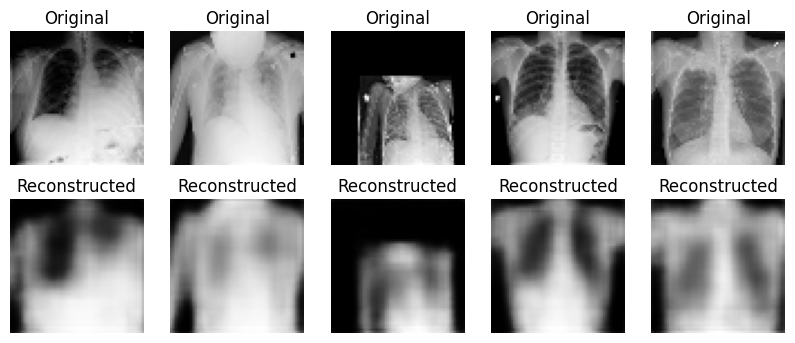

In [ ]:
# Visualize the original and reconstructed images
import matplotlib.pyplot as plt
n = 5 # Number of images to display
plt.figure(figsize=(10, 4))
for i in range(n):
 # Original image
 ax = plt.subplot(2, n, i + 1)
 plt.imshow(x_data[i].squeeze(), cmap='gray')
 plt.title('Original')
 plt.axis('off')
 # Reconstructed image
 ax = plt.subplot(2, n, i + 1 + n)
 plt.imshow(reconstructed_images[i].squeeze(), cmap='gray')
 plt.title('Reconstructed')
 plt.axis('off')
plt.show()